# Digital Transformation Business Impact Analysis
## Vos Automotive, Singapore: Proposed Digital Customization Platform

### Project Overview
Vos Automotive currently operates mainly through physical workshop consultation and walk-in visits.  
This project evaluates the business impact of introducing a **digital customization platform** where customers can:

- Browse services online
- Visualize modifications
- Compare options/packages
- Book appointments digitally

### Data Availability Note
Public company information is limited.  
Therefore, this notebook uses **reasoned assumptions** and **synthetic (simulated) analytics** for academic analysis.

This is **not internal company data**.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display, Markdown

# Reproducibility for synthetic data
np.random.seed(42)

# Display preferences
pd.set_option("display.max_columns", None)

def round_half_up(value: float) -> int:
    """Round halves up (e.g., 238.5 -> 239) for cleaner business projections."""
    return int(np.floor(value + 0.5))

def format_sgd(value: float) -> str:
    """Format numbers as SGD currency strings."""
    return f"SGD {value:,.0f}"

def show_currency_table(df: pd.DataFrame, currency_cols: list):
    """Display a DataFrame with selected columns formatted as SGD."""
    temp = df.copy()
    for col in currency_cols:
        temp[col] = temp[col].map(format_sgd)
    display(temp)


## 2. Company Baseline from Public Information

Public reference: https://vos.sg/automotive/about-us/

The following facts are publicly communicated by Vos Automotive:
- Established in 2020
- 1000+ happy customers
- 1000+ cars done
- 5+ years of aesthetic styling experience
- Located at OneKA @ Macpherson, 1 Kampong Ampat, #05-12, Singapore 368314
- Main services: car wraps, paint protection film, solar film tinting, spray, graphic design, bodykits


In [14]:
public_facts = [
    {"item": "Company", "value": "Vos Automotive (Singapore)"},
    {"item": "Established", "value": "2020"},
    {"item": "Happy Customers", "value": "1000+"},
    {"item": "Cars Done", "value": "1000+"},
    {"item": "Experience", "value": "5+ years in aesthetic styling"},
    {"item": "Location", "value": "OneKA @ Macpherson, 1 Kampong Ampat, #05-12, Singapore 368314"},
    {"item": "Core Services", "value": "Car Wraps, Paint Protection Film, Solar Film Tinting, Spray, Graphic Design, Bodykits"}
]

baseline_public_df = pd.DataFrame(public_facts)
display(baseline_public_df)


,item,value
0,Company,Vos Automotive (Singapore)
1,Established,2020
2,Happy Customers,1000+
3,Cars Done,1000+
4,Experience,5+ years in aesthetic styling
5,Location,"OneKA @ Macpherson, 1 Kampong Ampat, #05-12, S..."
6,Core Services,"Car Wraps, Paint Protection Film, Solar Film T..."


## 3. Assumptions for Modelling

Because internal operational and financial data is not publicly available, the following are **project assumptions** for scenario modelling:

- Current cumulative customers: 1000
- Analysis horizon: 5 years (strategy context)
- Estimated current annual customers: around 200
- Average order value: SGD 1,500
- Baseline organic annual customer growth (without platform): 6%
- Additional annual customer growth from digital platform: 15%
- Upsell / cross-sell lift from analytics recommendations: 8%
- Additional conversion lift from improved online journey: 5%

### Why these assumptions are reasonable
For a small but growing Singapore automotive styling workshop, moderate annual growth, realistic order values, and practical digital uplift rates are plausible for an academic business case.


In [15]:

assumptions = {
    "current_cumulative_customers": 1000,
    "analysis_horizon_years": 5,
    "historical_period": "2020-2024",
    "future_projection_period": "2025-2029",
    "estimated_current_annual_customers": 200,
    "average_order_value_sgd": 1500,
    "baseline_organic_growth_rate": 0.06,
    "digital_additional_growth_rate": 0.15,
    "conversion_lift_rate": 0.05,
    "analytics_upsell_lift_rate": 0.08
}

assumptions_df = pd.DataFrame({
    "assumption": [
        "Current cumulative customers",
        "Analysis horizon (years)",
        "Historical period",
        "Future projection period",
        "Estimated current annual customers",
        "Average order value",
        "Baseline organic annual growth",
        "Additional annual growth from digital platform",
        "Conversion lift from better online journey",
        "Upsell/cross-sell lift from analytics recommendations"
    ],
    "value": [
        assumptions["current_cumulative_customers"],
        assumptions["analysis_horizon_years"],
        assumptions["historical_period"],
        assumptions["future_projection_period"],
        assumptions["estimated_current_annual_customers"],
        format_sgd(assumptions["average_order_value_sgd"]),
        f"{assumptions['baseline_organic_growth_rate']:.0%}",
        f"{assumptions['digital_additional_growth_rate']:.0%}",
        f"{assumptions['conversion_lift_rate']:.0%}",
        f"{assumptions['analytics_upsell_lift_rate']:.0%}"
    ]
})

# Assumptions are project-level estimates for academic modelling, not internal company records.
display(assumptions_df)


,assumption,value
0,Current cumulative customers,1000
1,Analysis horizon (years),5
2,Historical period,2020-2024
3,Future projection period,2025-2029
4,Estimated current annual customers,200
5,Average order value,"SGD 1,500"
6,Baseline organic annual growth,6%
7,Additional annual growth from digital platform,15%
8,Conversion lift from better online journey,5%
9,Upsell/cross-sell lift from analytics recommen...,8%


## 4. Synthetic Historical Data Generation (2020-2024)

This synthetic dataset is created to reflect a plausible growth path consistent with Vos Automotive's public baseline (1000+ customers / cars done).

**Formula used:**
- `estimated_revenue = customers x average_order_value`


In [16]:
historical_df = pd.DataFrame({
    "year": [2020, 2021, 2022, 2023, 2024],
    "customers": [150, 175, 200, 220, 255],
    "average_order_value": [1300, 1360, 1420, 1470, 1500],
    "primary_service_mix": [
        "Car Wraps, Solar Film Tinting",
        "Car Wraps, Paint Protection Film",
        "Solar Film Tinting, Spray",
        "Paint Protection Film, Car Wraps",
        "Car Wraps, PPF, Bodykits"
    ]
})

historical_df["estimated_revenue"] = historical_df["customers"] * historical_df["average_order_value"]

historical_display = historical_df[["year", "customers", "average_order_value", "estimated_revenue", "primary_service_mix"]].copy()
historical_display["average_order_value"] = historical_display["average_order_value"].map(format_sgd)
historical_display["estimated_revenue"] = historical_display["estimated_revenue"].map(format_sgd)

display(historical_display)
print("Synthetic cumulative customers (2020-2024):", historical_df["customers"].sum())


,year,customers,average_order_value,estimated_revenue,primary_service_mix
0,2020,150,"SGD 1,300","SGD 195,000","Car Wraps, Solar Film Tinting"
1,2021,175,"SGD 1,360","SGD 238,000","Car Wraps, Paint Protection Film"
2,2022,200,"SGD 1,420","SGD 284,000","Solar Film Tinting, Spray"
3,2023,220,"SGD 1,470","SGD 323,400","Paint Protection Film, Car Wraps"
4,2024,255,"SGD 1,500","SGD 382,500","Car Wraps, PPF, Bodykits"


Synthetic cumulative customers (2020-2024): 1000



## 5. Baseline Future Projection (Without Digital Transformation)

Projection period: **2025-2029**  
Scenario assumes only baseline organic growth (6%).

For continuity, projections begin from the synthetic 2024 endpoint (255 customers).

**Formula:**
- `Projected Customers(t) = Customers(t-1) x (1 + baseline_growth)`
- `Baseline Revenue(t) = Projected Customers(t) x AOV`


In [17]:

projection_years = [2025, 2026, 2027, 2028, 2029]
aov = assumptions["average_order_value_sgd"]
baseline_growth = assumptions["baseline_organic_growth_rate"]

# Continuity fix: start projections from the last synthetic historical year (2024)
projection_start_customers = int(historical_df.iloc[-1]["customers"])
print(f"Projection start customers (from synthetic 2024): {projection_start_customers}")

baseline_projection_rows = []
prev_customers = projection_start_customers

for year in projection_years:
    customers = round_half_up(prev_customers * (1 + baseline_growth))
    revenue = customers * aov
    baseline_projection_rows.append({
        "year": year,
        "baseline_customers": customers,
        "baseline_revenue": revenue
    })
    prev_customers = customers

baseline_projection_df = pd.DataFrame(baseline_projection_rows)
show_currency_table(baseline_projection_df, ["baseline_revenue"])


Projection start customers (from synthetic 2024): 255


,year,baseline_customers,baseline_revenue
0,2025,270,"SGD 405,000"
1,2026,286,"SGD 429,000"
2,2027,303,"SGD 454,500"
3,2028,321,"SGD 481,500"
4,2029,340,"SGD 510,000"



## 6. Future Projection With Digital Customization Platform

Projection period: **2025-2029** using the same starting point as the baseline scenario.

This scenario adds:
- Additional customer growth from digital acquisition (+15% per year)
- Revenue conversion uplift (+5%) from a smoother online journey
- Upsell/cross-sell uplift (+8%) from analytics recommendations

**Formulas:**
- `Digital Customers(t) = Customers(t-1) x (1 + baseline_growth + digital_growth)`
- `Base Revenue = Digital Customers x AOV`
- `Revenue After Conversion = Base Revenue x (1 + conversion_lift)`
- `Digital Revenue = Revenue After Conversion x (1 + upsell_lift)`


In [18]:
digital_extra_growth = assumptions["digital_additional_growth_rate"]
conversion_lift = assumptions["conversion_lift_rate"]
upsell_lift = assumptions["analytics_upsell_lift_rate"]
total_digital_growth = baseline_growth + digital_extra_growth

digital_projection_rows = []
# Use the same 2024 starting point for fair scenario comparison
prev_customers = projection_start_customers

for year in projection_years:
    digital_customers = round_half_up(prev_customers * (1 + total_digital_growth))

    base_revenue = digital_customers * aov
    conversion_uplift = round_half_up(base_revenue * conversion_lift)
    revenue_after_conversion = base_revenue + conversion_uplift
    analytics_upsell_uplift = round_half_up(revenue_after_conversion * upsell_lift)
    digital_revenue = base_revenue + conversion_uplift + analytics_upsell_uplift

    digital_projection_rows.append({
        "year": year,
        "digital_customers": digital_customers,
        "base_revenue": base_revenue,
        "conversion_uplift": conversion_uplift,
        "analytics_upsell_uplift": analytics_upsell_uplift,
        "digital_revenue": digital_revenue
    })
    prev_customers = digital_customers

digital_projection_df = pd.DataFrame(digital_projection_rows)
show_currency_table(
    digital_projection_df,
    ["base_revenue", "conversion_uplift", "analytics_upsell_uplift", "digital_revenue"]
)


,year,digital_customers,base_revenue,conversion_uplift,analytics_upsell_uplift,digital_revenue
0,2025,309,"SGD 463,500","SGD 23,175","SGD 38,934","SGD 525,609"
1,2026,374,"SGD 561,000","SGD 28,050","SGD 47,124","SGD 636,174"
2,2027,453,"SGD 679,500","SGD 33,975","SGD 57,078","SGD 770,553"
3,2028,548,"SGD 822,000","SGD 41,100","SGD 69,048","SGD 932,148"
4,2029,663,"SGD 994,500","SGD 49,725","SGD 83,538","SGD 1,127,763"



## 7. Scenario Comparison

This section compares baseline vs digital scenario by year and calculates total uplift over the full 5-year projection period.


In [19]:

comparison_df = baseline_projection_df.merge(
    digital_projection_df[["year", "digital_customers", "digital_revenue"]],
    on="year",
    how="inner"
)

comparison_df["customer_difference"] = comparison_df["digital_customers"] - comparison_df["baseline_customers"]
comparison_df["revenue_difference"] = comparison_df["digital_revenue"] - comparison_df["baseline_revenue"]

comparison_df = comparison_df[
    ["year", "baseline_customers", "digital_customers", "customer_difference",
     "baseline_revenue", "digital_revenue", "revenue_difference"]
]

show_currency_table(comparison_df, ["baseline_revenue", "digital_revenue", "revenue_difference"])

total_customer_uplift = int(comparison_df["customer_difference"].sum())
total_revenue_uplift = int(comparison_df["revenue_difference"].sum())
projection_label = f"{projection_years[0]}-{projection_years[-1]}"

print(f"Total customer uplift ({projection_label}):", total_customer_uplift)
print(f"Total revenue uplift ({projection_label}):", format_sgd(total_revenue_uplift))

display(Markdown(
    f"**Interpretation:** Over {projection_label}, the digital platform scenario delivers higher demand and revenue in every year, resulting in measurable cumulative uplift versus baseline."
))


,year,baseline_customers,digital_customers,customer_difference,baseline_revenue,digital_revenue,revenue_difference
0,2025,270,309,39,"SGD 405,000","SGD 525,609","SGD 120,609"
1,2026,286,374,88,"SGD 429,000","SGD 636,174","SGD 207,174"
2,2027,303,453,150,"SGD 454,500","SGD 770,553","SGD 316,053"
3,2028,321,548,227,"SGD 481,500","SGD 932,148","SGD 450,648"
4,2029,340,663,323,"SGD 510,000","SGD 1,127,763","SGD 617,763"


Total customer uplift (2025-2029): 827
Total revenue uplift (2025-2029): SGD 1,712,247


**Interpretation:** Over 2025-2029, the digital platform scenario delivers higher demand and revenue in every year, resulting in measurable cumulative uplift versus baseline.

## 8. Visualisations (Matplotlib Only)


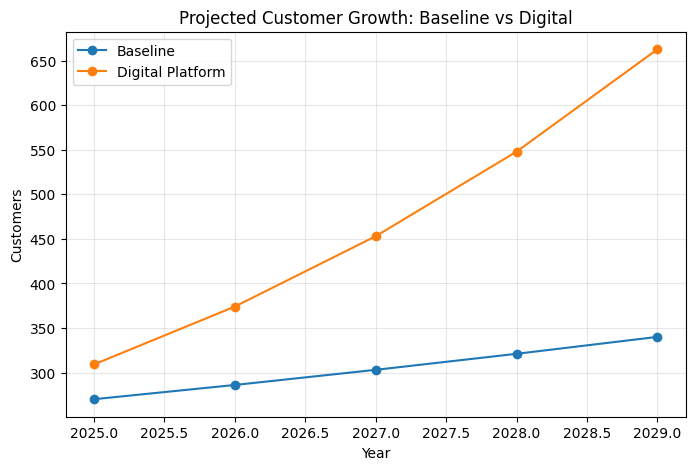

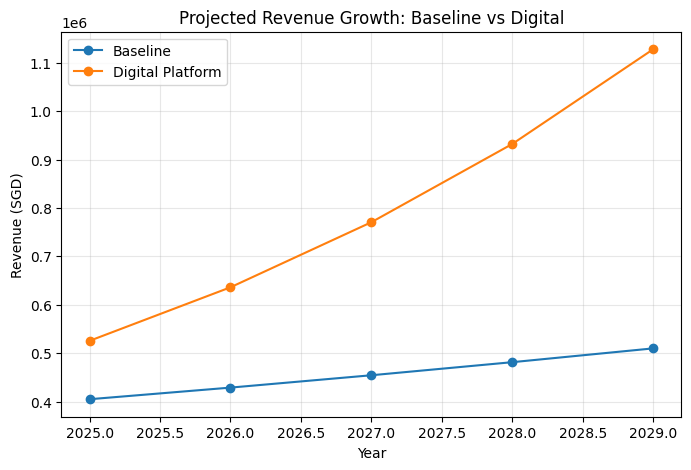

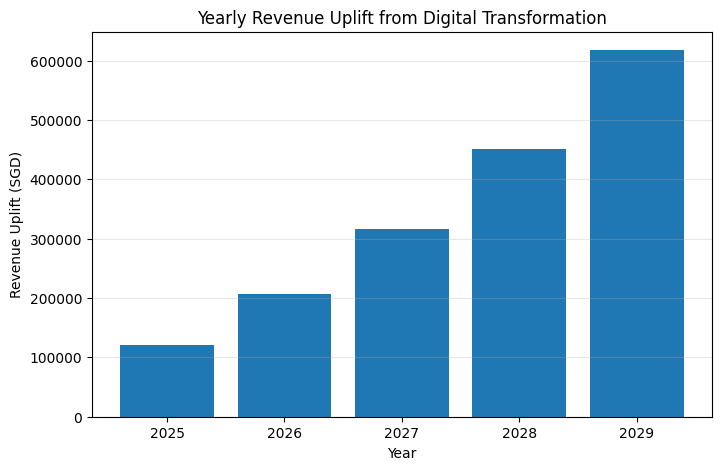

**Chart interpretation:** The digital scenario compounds over time, creating widening gaps in both customers and revenue by 2029.

In [20]:

# Customer growth: baseline vs digital
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["year"], comparison_df["baseline_customers"], marker="o", label="Baseline")
plt.plot(comparison_df["year"], comparison_df["digital_customers"], marker="o", label="Digital Platform")
plt.title("Projected Customer Growth: Baseline vs Digital")
plt.xlabel("Year")
plt.ylabel("Customers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Revenue growth: baseline vs digital
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["year"], comparison_df["baseline_revenue"], marker="o", label="Baseline")
plt.plot(comparison_df["year"], comparison_df["digital_revenue"], marker="o", label="Digital Platform")
plt.title("Projected Revenue Growth: Baseline vs Digital")
plt.xlabel("Year")
plt.ylabel("Revenue (SGD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Yearly revenue uplift bar chart
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["year"].astype(str), comparison_df["revenue_difference"])
plt.title("Yearly Revenue Uplift from Digital Transformation")
plt.xlabel("Year")
plt.ylabel("Revenue Uplift (SGD)")
plt.grid(axis="y", alpha=0.3)
plt.show()

display(Markdown(
    "**Chart interpretation:** The digital scenario compounds over time, creating widening gaps in both customers and revenue by 2029."
))



## 9. Synthetic Transaction Analytics

This section strengthens the post-purchase analytics layer with a richer synthetic order dataset.

**Synthetic fields included:**
- `customer_id`
- `car_model_segment` (sedan, hatchback, SUV, luxury)
- `primary_service`
- `secondary_service`
- `order_value`
- `customer_budget_band`
- `style_preference`

All data below is simulated/extrapolated for academic analysis, not internal company records.


In [21]:

services = [
    "Car Wrap",
    "Paint Protection Film",
    "Solar Film Tinting",
    "Spray",
    "Graphic Design",
    "Bodykit"
]

car_segments = ["sedan", "hatchback", "SUV", "luxury"]
car_segment_probs = np.array([0.38, 0.20, 0.30, 0.12])

style_preferences = ["sporty", "premium", "minimalist", "family"]
style_probs = np.array([0.30, 0.22, 0.23, 0.25])

# Style-based service tendencies (plausible workshop demand patterns)
service_weights_by_style = {
    "sporty": {
        "Car Wrap": 0.30,
        "Paint Protection Film": 0.18,
        "Solar Film Tinting": 0.14,
        "Spray": 0.16,
        "Graphic Design": 0.07,
        "Bodykit": 0.15
    },
    "premium": {
        "Car Wrap": 0.17,
        "Paint Protection Film": 0.30,
        "Solar Film Tinting": 0.20,
        "Spray": 0.10,
        "Graphic Design": 0.05,
        "Bodykit": 0.18
    },
    "minimalist": {
        "Car Wrap": 0.14,
        "Paint Protection Film": 0.25,
        "Solar Film Tinting": 0.30,
        "Spray": 0.10,
        "Graphic Design": 0.12,
        "Bodykit": 0.09
    },
    "family": {
        "Car Wrap": 0.18,
        "Paint Protection Film": 0.27,
        "Solar Film Tinting": 0.28,
        "Spray": 0.11,
        "Graphic Design": 0.06,
        "Bodykit": 0.10
    }
}

# Typical secondary add-on mapping by primary service
secondary_candidates = {
    "Car Wrap": (["Solar Film Tinting", "Paint Protection Film", "Graphic Design", "Bodykit"], [0.40, 0.30, 0.20, 0.10]),
    "Paint Protection Film": (["Solar Film Tinting", "Car Wrap", "Bodykit"], [0.50, 0.35, 0.15]),
    "Solar Film Tinting": (["Paint Protection Film", "Car Wrap", "Graphic Design"], [0.45, 0.40, 0.15]),
    "Spray": (["Bodykit", "Car Wrap", "Graphic Design"], [0.45, 0.35, 0.20]),
    "Graphic Design": (["Car Wrap", "Spray", "Solar Film Tinting"], [0.50, 0.30, 0.20]),
    "Bodykit": (["Spray", "Car Wrap", "Paint Protection Film"], [0.45, 0.35, 0.20])
}

base_service_price = {
    "Car Wrap": 1800,
    "Paint Protection Film": 2200,
    "Solar Film Tinting": 900,
    "Spray": 1300,
    "Graphic Design": 700,
    "Bodykit": 2500
}

segment_multiplier = {
    "sedan": 1.00,
    "hatchback": 0.92,
    "SUV": 1.10,
    "luxury": 1.25
}

style_multiplier = {
    "sporty": 1.06,
    "premium": 1.10,
    "minimalist": 0.97,
    "family": 1.00
}

rng = np.random.default_rng(42)
n_customers_tx = 320

transaction_rows = []
for cid in range(1, n_customers_tx + 1):
    car_model_segment = rng.choice(car_segments, p=car_segment_probs)
    style_preference = rng.choice(style_preferences, p=style_probs)

    primary_weights = np.array([service_weights_by_style[style_preference][svc] for svc in services], dtype=float)
    primary_weights = primary_weights / primary_weights.sum()
    primary_service = rng.choice(services, p=primary_weights)

    secondary_service = None
    if rng.random() < 0.72:
        sec_options, sec_probs = secondary_candidates[primary_service]
        secondary_service = rng.choice(sec_options, p=sec_probs)

    order_value = base_service_price[primary_service]
    if secondary_service is not None:
        order_value += base_service_price[secondary_service] * rng.uniform(0.55, 0.80)

    order_value *= segment_multiplier[car_model_segment]
    order_value *= style_multiplier[style_preference]
    order_value *= rng.uniform(0.92, 1.08)
    order_value = round_half_up(order_value)

    if order_value <= 1800:
        customer_budget_band = "Value (<= SGD 1,800)"
    elif order_value <= 3200:
        customer_budget_band = "Mid (SGD 1,801-3,200)"
    else:
        customer_budget_band = "Premium (> SGD 3,200)"

    transaction_rows.append({
        "customer_id": f"C{cid:03d}",
        "car_model_segment": car_model_segment,
        "primary_service": primary_service,
        "secondary_service": secondary_service,
        "order_value": order_value,
        "customer_budget_band": customer_budget_band,
        "style_preference": style_preference
    })

transactions_df = pd.DataFrame(transaction_rows)

display(transactions_df.head(12))
print("Synthetic customer orders:", len(transactions_df))
print("Average synthetic order value:", format_sgd(transactions_df["order_value"].mean()))


,customer_id,car_model_segment,primary_service,secondary_service,order_value,customer_budget_band,style_preference
0,C001,SUV,Bodykit,Spray,4452,"Premium (> SGD 3,200)",premium
1,C002,SUV,Paint Protection Film,Bodykit,4877,"Premium (> SGD 3,200)",sporty
2,C003,hatchback,Solar Film Tinting,Car Wrap,2208,"Mid (SGD 1,801-3,200)",sporty
3,C004,sedan,Graphic Design,None,666,"Value (<= SGD 1,800)",family
4,C005,hatchback,Car Wrap,Graphic Design,2232,"Mid (SGD 1,801-3,200)",sporty
5,C006,sedan,Paint Protection Film,Solar Film Tinting,3103,"Mid (SGD 1,801-3,200)",premium
6,C007,hatchback,Solar Film Tinting,Car Wrap,2035,"Mid (SGD 1,801-3,200)",family
7,C008,sedan,Car Wrap,Solar Film Tinting,2461,"Mid (SGD 1,801-3,200)",minimalist
8,C009,SUV,Solar Film Tinting,Paint Protection Film,2455,"Mid (SGD 1,801-3,200)",family
9,C010,hatchback,Spray,Car Wrap,2197,"Mid (SGD 1,801-3,200)",minimalist


Synthetic customer orders: 320
Average synthetic order value: SGD 2,666


In [22]:

# Most popular services (counting both primary and secondary mentions)
service_mentions = pd.concat(
    [
        transactions_df["primary_service"],
        transactions_df["secondary_service"].dropna()
    ],
    ignore_index=True
)

popular_services_df = (
    service_mentions
    .value_counts()
    .rename_axis("service")
    .reset_index(name="order_count")
)

display(popular_services_df)

# Most frequent service bundles
bundle_df = transactions_df.dropna(subset=["secondary_service"]).copy()
bundle_df["service_bundle"] = bundle_df.apply(
    lambda row: " + ".join(sorted([row["primary_service"], row["secondary_service"]])),
    axis=1
)

bundle_counts_df = (
    bundle_df["service_bundle"]
    .value_counts()
    .rename_axis("bundle")
    .reset_index(name="order_count")
)

display(bundle_counts_df.head(10))

# Average order value by primary service
aov_by_primary_service_df = (
    transactions_df.groupby("primary_service", as_index=False)["order_value"]
    .mean()
    .rename(columns={"order_value": "avg_order_value"})
    .sort_values("avg_order_value", ascending=False)
)
aov_by_primary_service_df["avg_order_value"] = aov_by_primary_service_df["avg_order_value"].round(0).astype(int)
show_currency_table(aov_by_primary_service_df, ["avg_order_value"])

# Average order value by budget band
aov_by_budget_band_df = (
    transactions_df.groupby("customer_budget_band", as_index=False)
    .agg(avg_order_value=("order_value", "mean"), order_count=("order_value", "size"))
)
aov_by_budget_band_df["avg_order_value"] = aov_by_budget_band_df["avg_order_value"].round(0).astype(int)
show_currency_table(aov_by_budget_band_df, ["avg_order_value"])

# Top bundles by style preference
top_bundles_by_style_df = (
    bundle_df.groupby(["style_preference", "service_bundle"], as_index=False)
    .size()
    .rename(columns={"size": "order_count"})
    .sort_values(["style_preference", "order_count"], ascending=[True, False])
    .groupby("style_preference", as_index=False)
    .head(3)
)

display(top_bundles_by_style_df)

display(Markdown(
    "**Interpretation:** Bundled purchases are common in this synthetic dataset, supporting the case for digital recommendations that promote practical add-on services."
))


,service,order_count
0,Car Wrap,136
1,Solar Film Tinting,124
2,Paint Protection Film,114
3,Bodykit,80
4,Spray,51
5,Graphic Design,44


,bundle,order_count
0,Paint Protection Film + Solar Film Tinting,49
1,Car Wrap + Solar Film Tinting,43
2,Car Wrap + Paint Protection Film,28
3,Bodykit + Spray,27
4,Bodykit + Car Wrap,25
5,Car Wrap + Graphic Design,15
6,Graphic Design + Solar Film Tinting,13
7,Bodykit + Paint Protection Film,12
8,Graphic Design + Spray,10
9,Car Wrap + Spray,7


,primary_service,avg_order_value
0,Bodykit,"SGD 3,632"
3,Paint Protection Film,"SGD 3,021"
1,Car Wrap,"SGD 2,730"
5,Spray,"SGD 2,575"
4,Solar Film Tinting,"SGD 1,905"
2,Graphic Design,"SGD 1,454"


,customer_budget_band,avg_order_value,order_count
0,"Mid (SGD 1,801-3,200)","SGD 2,485",173
1,"Premium (> SGD 3,200)","SGD 3,862",92
2,"Value (<= SGD 1,800)","SGD 1,237",55


,style_preference,service_bundle,order_count
8,family,Paint Protection Film + Solar Film Tinting,13
4,family,Car Wrap + Solar Film Tinting,10
3,family,Car Wrap + Paint Protection Film,7
14,minimalist,Car Wrap + Solar Film Tinting,13
18,minimalist,Paint Protection Film + Solar Film Tinting,11
12,minimalist,Car Wrap + Graphic Design,4
26,premium,Paint Protection Film + Solar Film Tinting,19
21,premium,Bodykit + Spray,9
23,premium,Car Wrap + Paint Protection Film,9
32,sporty,Car Wrap + Solar Film Tinting,14


**Interpretation:** Bundled purchases are common in this synthetic dataset, supporting the case for digital recommendations that promote practical add-on services.

In [23]:

# Basic recommendation logic from observed synthetic co-purchase patterns
order_service_sets = transactions_df.apply(
    lambda row: {row["primary_service"]} | ({row["secondary_service"]} if pd.notna(row["secondary_service"]) else set()),
    axis=1
)

all_services = sorted(popular_services_df["service"].unique())
recommendation_rows = []

for service_x in all_services:
    buyers_x = order_service_sets[order_service_sets.apply(lambda purchased: service_x in purchased)]
    support_x = len(buyers_x)

    # Keep only stable patterns with enough support
    if support_x < 15:
        continue

    best_service = None
    best_conf = 0.0
    best_support = 0

    for service_y in all_services:
        if service_y == service_x:
            continue

        support_xy = buyers_x.apply(lambda purchased: service_y in purchased).sum()
        confidence = support_xy / support_x

        if confidence > best_conf:
            best_conf = confidence
            best_service = service_y
            best_support = int(support_xy)

    recommendation_rows.append({
        "if_customer_buys": service_x,
        "recommend_next": best_service,
        "confidence": best_conf,
        "support_customers": best_support
    })

recommendation_df = pd.DataFrame(recommendation_rows).sort_values(
    ["confidence", "support_customers"], ascending=False
).reset_index(drop=True)

recommendation_display = recommendation_df.copy()
recommendation_display["confidence"] = (recommendation_display["confidence"] * 100).round(1).astype(str) + "%"

display(recommendation_display)


,if_customer_buys,recommend_next,confidence,support_customers
0,Spray,Bodykit,52.9%,27
1,Paint Protection Film,Solar Film Tinting,43.0%,49
2,Solar Film Tinting,Paint Protection Film,39.5%,49
3,Graphic Design,Car Wrap,34.1%,15
4,Bodykit,Spray,33.8%,27
5,Car Wrap,Solar Film Tinting,31.6%,43



## 10. AI-Powered Recommendation and Insight Layer

This layer uses the computed analytics outputs as context for an AI assistant.

Important:
- The AI does **not** replace numeric calculations from pandas/numpy.
- The AI interprets existing analytics and generates business-facing recommendations.
- If no API key is available, the notebook prints the constructed prompt so logic remains transparent.


In [24]:

import os
import json

sample_customer_profile = {
    "selected_service": "Car Wrap",
    "budget_sgd": 2500,
    "style_preference": "sporty",
    "car_model_segment": "sedan"
}

analytics_summary = {
    "projection_period": f"{projection_years[0]}-{projection_years[-1]}",
    "total_customer_uplift": total_customer_uplift,
    "total_revenue_uplift_sgd": total_revenue_uplift,
    "top_services": popular_services_df.head(5).to_dict("records"),
    "top_service_bundles": bundle_counts_df.head(5).to_dict("records"),
    "aov_by_primary_service": aov_by_primary_service_df.to_dict("records"),
    "aov_by_budget_band": aov_by_budget_band_df.to_dict("records"),
    "top_recommendation_rules": recommendation_df.head(5).to_dict("records")
}


def build_ai_prompt(analytics_payload: dict, customer_profile: dict) -> str:
    """Build a grounded prompt using analytics outputs from this notebook."""
    return f"""
You are an analytics copilot for a Singapore automotive styling business.
Use ONLY the provided analytics summary to produce recommendations.

Analytics summary (JSON):
{json.dumps(analytics_payload, indent=2)}

Sample customer profile (JSON):
{json.dumps(customer_profile, indent=2)}

Return output in two sections:
1) Customer Recommendation
- Recommend 2-3 add-on services.
- Give short reason for each recommendation based on service patterns, budget fit, style preference, and car segment.

2) Management Insight
- One concise paragraph for management on promising bundles, valuable customer segments, and how digital platform features support upsell/cross-sell.

Do not invent new numeric metrics.
""".strip()


def generate_ai_recommendation(analytics_payload: dict, customer_profile: dict, model: str = "gpt-4.1-mini"):
    """
    Calls OpenAI to interpret analytics and generate recommendations.
    Fallback behavior: if API key or package is unavailable, print prompt only.
    """
    prompt = build_ai_prompt(analytics_payload, customer_profile)
    api_key = os.getenv("OPENAI_API_KEY")

    if not api_key:
        print("OPENAI_API_KEY not found. Prompt preview below:")
        print()
        print(prompt)
        return None

    try:
        from openai import OpenAI
    except ImportError:
        print("openai package not installed. Prompt preview below:")
        print()
        print(prompt)
        return None

    client = OpenAI(api_key=api_key)
    response = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": "You are a concise business analytics assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2
    )
    return response.output_text


ai_response_text = generate_ai_recommendation(analytics_summary, sample_customer_profile)

if ai_response_text:
    display(Markdown(f"""### AI Output\n\n{ai_response_text}"""))


OPENAI_API_KEY not found. Prompt preview below:

You are an analytics copilot for a Singapore automotive styling business.
Use ONLY the provided analytics summary to produce recommendations.

Analytics summary (JSON):
{
  "projection_period": "2025-2029",
  "total_customer_uplift": 827,
  "total_revenue_uplift_sgd": 1712247,
  "top_services": [
    {
      "service": "Car Wrap",
      "order_count": 136
    },
    {
      "service": "Solar Film Tinting",
      "order_count": 124
    },
    {
      "service": "Paint Protection Film",
      "order_count": 114
    },
    {
      "service": "Bodykit",
      "order_count": 80
    },
    {
      "service": "Spray",
      "order_count": 51
    }
  ],
  "top_service_bundles": [
    {
      "bundle": "Paint Protection Film + Solar Film Tinting",
      "order_count": 49
    },
    {
      "bundle": "Car Wrap + Solar Film Tinting",
      "order_count": 43
    },
    {
      "bundle": "Car Wrap + Paint Protection Film",
      "order_count": 28
   


## 11. Key Business Findings
The following slide-ready insights are generated from the model outputs.


In [25]:

projection_label = f"{projection_years[0]}-{projection_years[-1]}"
avg_yearly_revenue_uplift = int(round(comparison_df["revenue_difference"].mean(), 0))

top_service = popular_services_df.iloc[0]["service"]
top_service_share = popular_services_df.iloc[0]["order_count"] / popular_services_df["order_count"].sum()

top_rule = recommendation_df.iloc[0]
top_bundle = bundle_counts_df.iloc[0]

insights_md = f"""
- **Projected customer impact ({projection_label}):** Digital transformation adds approximately **{total_customer_uplift} customers** versus baseline.
- **Projected revenue impact ({projection_label}):** Digital scenario generates about **{format_sgd(total_revenue_uplift)}** additional revenue.
- **Average annual uplift:** Roughly **{format_sgd(avg_yearly_revenue_uplift)}** incremental revenue per year.
- **High-value bundle signal:** The most frequent bundle is **{top_bundle['bundle']}**, indicating strong add-on potential for digital package recommendations.
- **Service demand mix:** Top service mention is **{top_service}** (about **{top_service_share:.0%}** of total service mentions), supporting front-page prioritization in the digital catalog.
- **Cross-sell pattern:** Strongest rule in synthetic data is **{top_rule['if_customer_buys']} -> {top_rule['recommend_next']}** (confidence **{top_rule['confidence']:.0%}**), useful for next-best-offer prompts.
- **Business implication:** Combining online discovery, guided comparison, booking convenience, and analytics-based recommendations can lift both demand and revenue quality.
"""
display(Markdown(insights_md))



- **Projected customer impact (2025-2029):** Digital transformation adds approximately **827 customers** versus baseline.
- **Projected revenue impact (2025-2029):** Digital scenario generates about **SGD 1,712,247** additional revenue.
- **Average annual uplift:** Roughly **SGD 342,449** incremental revenue per year.
- **High-value bundle signal:** The most frequent bundle is **Paint Protection Film + Solar Film Tinting**, indicating strong add-on potential for digital package recommendations.
- **Service demand mix:** Top service mention is **Car Wrap** (about **25%** of total service mentions), supporting front-page prioritization in the digital catalog.
- **Cross-sell pattern:** Strongest rule in synthetic data is **Spray -> Bodykit** (confidence **53%**), useful for next-best-offer prompts.
- **Business implication:** Combining online discovery, guided comparison, booking convenience, and analytics-based recommendations can lift both demand and revenue quality.



## 12. Conclusion

This notebook provides a structured business-case analysis for a proposed digital customization platform for **Vos Automotive**.

Using public company facts, reasoned assumptions, and synthetic analytics:
- Baseline and digital scenarios were projected consistently across a 5-year future horizon (2025-2029)
- Revenue and customer uplifts were quantified under both scenarios
- Enhanced transaction analytics identified practical bundling and segment patterns
- An AI-powered interpretation layer translated analytics results into customer recommendations and management insights

Overall, the analysis supports the strategic justification that a digital customization platform can strengthen growth, customer experience, and monetization for a modern automotive styling business in Singapore.

**Important note:** All historical and forward-looking figures in this notebook are synthetic/extrapolated for academic analysis and should not be interpreted as actual internal company performance data.
